# VE-SDE NCSN++ on CIFAR-10 Birds without Augmentation

Load and evaluate a trained VE-SDE NCSN++ checkpoint on plain CIFAR-10 bird images.


In [ ]:
import os
import sys
import math
import copy
import subprocess
from types import SimpleNamespace

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import tqdm


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Configuration


In [ ]:
# Evaluation mode
TRAINING = False
RUN_TRAINING = False
RUN_EVALUATION_AFTER_LOADING = True

# Sampling and evaluation settings
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 1

fid_num_generated = 1000
fid_gen_batch_size = 64
fid_real_max_images = 1000

mem_num_generated = 64
mem_reference_images = 5000
mem_generation_batch_size = 64


## Imports


In [ ]:
# Connect to Drive and define paths

from google.colab import drive

# Folder containing the trained checkpoint.
path = "/content/drive/MyDrive/DD2424/Project/working_nets"

# Requested checkpoint. The first candidate is the corrected full .pth path.
# The last two candidates also cover the exact string if it exists without the slash/extension.
checkpoint_candidates = [
    os.path.join(path, "bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth"),
    os.path.join(path, "bird_ncsnpp_ve_ema_checkpoint_epoch_1760"),
    "/content/drive/MyDrive/DD2424/Project/working_netsbird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth",
    "/content/drive/MyDrive/DD2424/Project/working_netsbird_ncsnpp_ve_ema_checkpoint_epoch_1760",
]

try:
    drive.mount("/content/drive")
except ValueError:
    pass # Already mounted

os.makedirs(path, exist_ok=True)

project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

CHECKPOINT_TO_LOAD = next((candidate for candidate in checkpoint_candidates if os.path.exists(candidate)), checkpoint_candidates[0])

print("Project path:", path)
print("Checkpoint to load:", CHECKPOINT_TO_LOAD)
print("Files in project path:", os.listdir(path))


Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project/working_nets
Checkpoint to load: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth
Files in project path: ['score_sde_pytorch', 'bird_ncsnpp_ve_ema_checkpoint_epoch_500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_621.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1000.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1759.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth', 'bird_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth', 'non_augmented_ema_generated_samples_grid.png', 'non_augmented_vp_generated_samples_grid.png', 'non_augmented_comparison_raw_vp_net_grid.png', 'non_augmented_comparison_ema_net_grid.png', 'raw_vp_net_bird_non_augmented_1760_epochs_generated_grid.png', 'flower_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth', 'raw_vp_net_bird_non_augmented_1760_epochs_evaluation_results.txt', 'ema_generated_samples_g

In [ ]:
from src.configs import create_ncsnpp_ve_config
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images
from src.sde import update_ema


## Load CIFAR-10 Data


In [ ]:
transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size=128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

target_idx = trainset.classes.index("bird")

train_indices = [i for i, label in enumerate(trainset.targets)
if label == target_idx]

trainset = Subset(trainset, train_indices)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

test_indices = [i for i, label in enumerate(testset.targets) if label == target_idx]

testset = Subset(testset, test_indices)


testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

#Make data on device for CUDA


100%|██████████| 170M/170M [00:05<00:00, 28.7MB/s]


In [ ]:
!pip install ninja


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.2 MB/s eta 0:00:00


## Import Score Model Architecture


In [ ]:
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ninja", "ml-collections"], check=False)

score_sde_repository_path = os.path.join(path, "score_sde_pytorch")

if not os.path.exists(score_sde_repository_path):
    subprocess.run(['git', 'clone', 'https://github.com/yang-song/score_sde_pytorch.git', score_sde_repository_path], check=True)

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp

print("Imported NCSNpp architecture")


Imported NCSNpp architecture


## SDE Objective


In [ ]:
def sigma_t(t, sigma_min=0.01, sigma_max=50.0):
    return sigma_min * (sigma_max / sigma_min) ** t


def perturbation_kernel(t, x0, sigma_min=0.01, sigma_max=50.0):
    mean = x0
    std = sigma_t(t, sigma_min, sigma_max).view(-1, 1, 1, 1)
    return mean, std


def cont_loss(x0, net):
    B = x0.shape[0]

    eps=1e-5
    t = torch.rand(B, device=x0.device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_pred = net(x_t, t)

    loss = ((score_pred * std + z) ** 2).mean()

    return loss


## Import Score Model Architecture


In [ ]:
class NCSNppVEScoreWrapper(nn.Module):
    def __init__(self, official_model):
        super().__init__()
        self.official_model = official_model

    def forward(self, images, continuous_timesteps):
        sigmas = sigma_t(continuous_timesteps)
        return self.official_model(images, sigmas)


## Load the trained checkpoint

This section builds the NCSN++ score model and loads the saved EMA checkpoint.

No new optimization is performed because

$$
\texttt{TRAINING} = \texttt{False}.
$$


In [ ]:
ncsnpp_config = create_ncsnpp_ve_config(image_size=32, image_channels=3)

official_ddpmpp_model = NCSNpp(ncsnpp_config).to(device)

ve_net = NCSNppVEScoreWrapper(official_model=official_ddpmpp_model).to(device)

number_of_parameters = sum(parameter.numel() for parameter in ve_net.parameters())
print("ncsn+ style model params", number_of_parameters)


ncsn+ style model params 62758915


In [ ]:
learning_rate = 2e-4
ema_decay=0.999
epochs=1760

optimizer = optim.Adam(ve_net.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08)

ema_net = copy.deepcopy(ve_net).to(device)
ema_net.eval()

for p in ema_net.parameters():
    p.requires_grad_(False)


if TRAINING:
    resume_epoch = 621
    resume_checkpoint_path = os.path.join(path, f'bird_ncsnpp_ve_ema_checkpoint_epoch_{resume_epoch}.pth')

    checkpoint = torch.load(resume_checkpoint_path, map_location=device, weights_only=False)

    ve_net.load_state_dict(checkpoint["ncsnpp"])
    ema_net.load_state_dict(checkpoint["ema_net"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    loss_hist = checkpoint.get("loss_hist", [])

    start_epoch=resume_epoch + 1

    print(f"Resumed from epoch {resume_epoch}. Starting at epoch {start_epoch} ending at {epochs}.")

    for epoch in tqdm.tqdm(range(start_epoch, epochs)):
        ve_net.train()
        epoch_losses = []

    for i, (images, _) in enumerate(trainloader):
        images = images.to(device)

        loss = cont_loss(images, ve_net)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ve_net.parameters(), max_norm=1.0)
        optimizer.step()

        update_ema(ema_net, ve_net, decay=ema_decay)

        epoch_losses.append(loss.item())

        loss_hist.append(np.mean(epoch_losses))

    if epoch % 10 == 0:
        print(f"VE epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

    if epoch % 500 == 0 or epoch == epochs - 1:
        checkpoint_path = os.path.join(path, f'bird_ncsnpp_ve_ema_checkpoint_epoch_{epoch}.pth')

        torch.save({'ncsnpp': ve_net.state_dict(), 'ema_net': ema_net.state_dict(), 'optimizer': optimizer.state_dict(), 'loss_hist': loss_hist, 'epochs': epoch}, checkpoint_path)

        print("Saved checkpoint:", checkpoint_path)

else:
    assert os.path.exists(CHECKPOINT_TO_LOAD), f"Checkpoint not found: {CHECKPOINT_TO_LOAD}"

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device, weights_only=False)

    if "ncsnpp" in checkpoint:
        ve_net.load_state_dict(checkpoint["ncsnpp"])
    elif "ve_net" in checkpoint:
        ve_net.load_state_dict(checkpoint["ve_net"])
    else:
        raise KeyError("Checkpoint must contain key 'ncsnpp' or 've_net'.")

    if "ema_net" in checkpoint:
        ema_net.load_state_dict(checkpoint["ema_net"])
    else:
        ema_net.load_state_dict(ve_net.state_dict())
        print("No EMA weights found. Copied raw VE weights into ema_net.")

    if "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])

        loss_hist = checkpoint.get("loss_hist", [])
        loaded_epoch = checkpoint.get("epochs", 1760)

        ve_net.eval()
        ema_net.eval()

    for p in ve_net.parameters():
        p.requires_grad_(False)

    for p in ema_net.parameters():
        p.requires_grad_(False)

        print("Loaded checkpoint successfully.")
        print("Loaded epoch:", loaded_epoch)
        print("Training disabled:", not TRAINING)
        print("Loss history length:", len(loss_hist))


Loaded checkpoint successfully.
Loaded epoch: 1760
Training disabled: True
Loss history length: 1758


## Checkpoint saving

Saving is only used when training is enabled. In evaluation mode this cell does not write a new checkpoint.


In [ ]:
if TRAINING:
    final_checkpoint_path = os.path.join(path, 'bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth')

    torch.save({'ncsnpp': ve_net.state_dict(), 'ema_net': ema_net.state_dict(), 'optimizer': optimizer.state_dict(), 'loss_hist': loss_hist, 'epochs': epochs}, final_checkpoint_path)

    print("Saved final checkpoint:", final_checkpoint_path)
else:
    print("Skipping checkpoint saving because TRAINING=False.")


Skipping checkpoint saving because TRAINING=False.


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):

    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)

        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


In [ ]:
@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


In [ ]:
@torch.no_grad()
def langevin_corrector_ve(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    batch_size_local = x.shape[0]
    batch_t = torch.ones(batch_size_local, device=x.device) * t

    for _ in range(n_steps):
        noise = torch.randn_like(x)
        score = net(x, batch_t)

        score_norm = torch.norm(score.reshape(batch_size_local, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(batch_size_local, -1), dim=1).mean()

        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


In [ ]:
def g_squared_t(batch_t, sigma_min=0.01, sigma_max=50):
    sig_t = sigma_t(batch_t, sigma_min, sigma_max)
    return 2.0 * (sig_t ** 2) * math.log(sigma_max / sigma_min)


In [ ]:
@torch.no_grad()
def euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    g_squared = g_squared_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = g_squared * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(g_squared * h) * noise
    else:
        x = x_mean

    return x, x_mean


## Sampling


In [ ]:
@torch.no_grad()
def sample_ve_sde_final(net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=1, denoise=True, sigma_max=50.0):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device) * sigma_max
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm.tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

    sample = x_mean if denoise else x
    return sample.clamp(-1, 1)


@torch.no_grad()
def sample_pc_ve_sde_continuous(net, num_pics=4, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=1, denoise=True, sigma_max=50.0):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device) * sigma_max
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x
    list_diff = []
    save_pic_it = max(1, num_steps // max(1, num_pics - 1))

    for i in tqdm.tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_ve(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_ve(x, t, t_next, net, add_noise=add_noise)

        if (i % save_pic_it) == 0:
            sample_to_save = x_mean if denoise else x
            list_diff.append(sample_to_save.clamp(-1, 1).cpu())
            sample_to_save = x_mean if denoise else x
            list_diff.append(sample_to_save.clamp(-1, 1).cpu())

    return torch.stack(list_diff, dim=0)


@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=1, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_ve_sde_final(
            net=model, num_samples=current_batch, img_shape=img_shape,
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


100%|██████████| 99/99 [00:03<00:00, 31.45it/s]


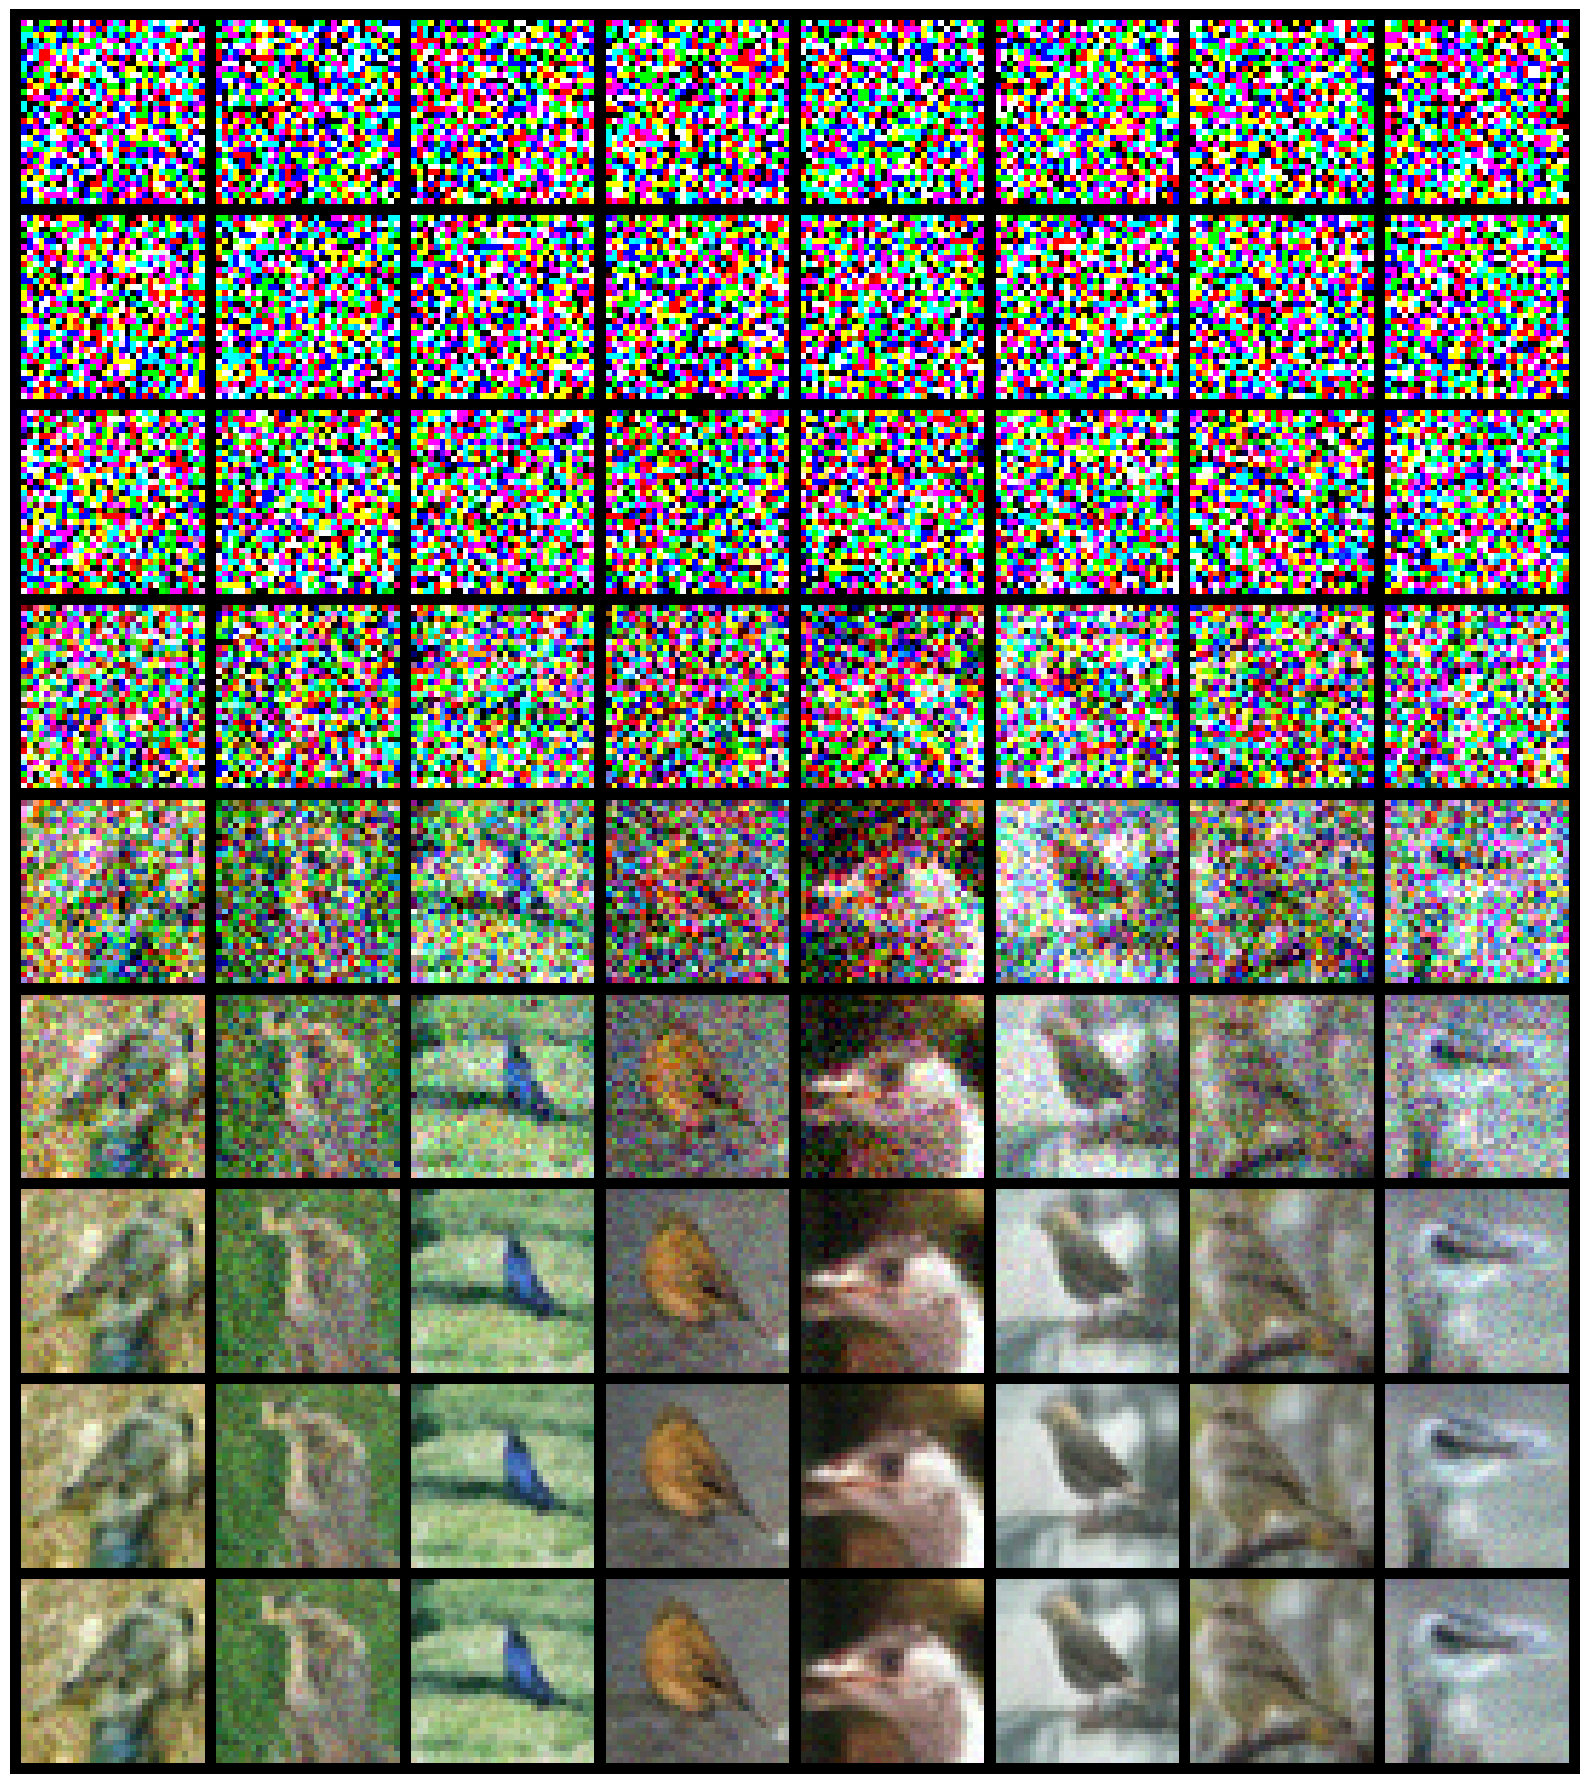

In [ ]:
samples_pc = sample_pc_ve_sde_continuous(net=ema_net, num_pics=8, num_samples=8, img_shape=(3, 32, 32),
    num_steps=100, eps=1e-3, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

num_pics, num_samples=samples_pc.shape[:2]

samples_flat = samples_pc.detach().cpu().reshape(num_pics * num_samples, *samples_pc.shape[2:])

grid = make_grid(samples_flat, nrow=8, padding=2, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(16, 2 * num_pics))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.tight_layout()
plt.show()


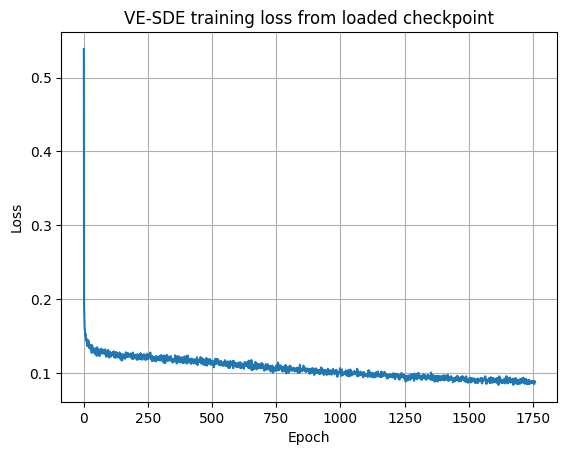

In [ ]:
if len(loss_hist) > 0:
    plt.figure()
    plt.plot(loss_hist)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("VE-SDE training loss from loaded checkpoint")
    plt.grid(True)
    plt.show()
else:
    print("No loss history found in the loaded checkpoint.")


## FID and memorization evaluation

FID compares generated images with real images using Inception features:

$$
FID = \|\mu_r - \mu_g\|_2^2 + \operatorname{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r\Sigma_g)^{1/2}).
$$

The memorization check compares each generated image with its nearest training image using

$$
d(g_i,x_j)=\frac{1}{CHW}\|g_i-x_j\|_2^2.
$$

Very small nearest-neighbor distances, especially with visually similar pairs, can indicate memorization.


In [ ]:
def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=1, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_ve_sde_final(
            net=model, num_samples=current_batch, img_shape=(3, 32, 32),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


def run_full_evaluation(model, model_name="bird_ncsnpp_ve_ema_epoch_1760", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=1):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=sample_eps, snr=sample_snr, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=fid_real_max_images, num_steps=num_steps, eps=sample_eps, snr=sample_snr, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader, num_generated=mem_num_generated, generation_batch_size=mem_generation_batch_size,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=sample_eps, snr=sample_snr,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)
    mem_report_path = os.path.join(path, f'{model_name}_memorization_report.txt')
    save_memorization_report(mem_results, mem_report_path)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


## Optional raw model versus EMA comparison

This uses the same random seed for both samplers so that visual differences mainly come from the weights rather than the initial noise.


In [ ]:
def compare_raw_vs_ema(raw_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=1):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=raw_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=sample_eps, snr=sample_snr, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=sample_eps, snr=sample_snr, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw VE model samples", nrow=8)
    show_images(samples_ema[:64], title="EMA VE model samples", nrow=8)
    return samples_raw, samples_ema



Running full evaluation for: bird_ncsnpp_ve_ema_epoch_1760


100%|██████████| 999/999 [00:52<00:00, 19.14it/s]


Generated 64/64 samples


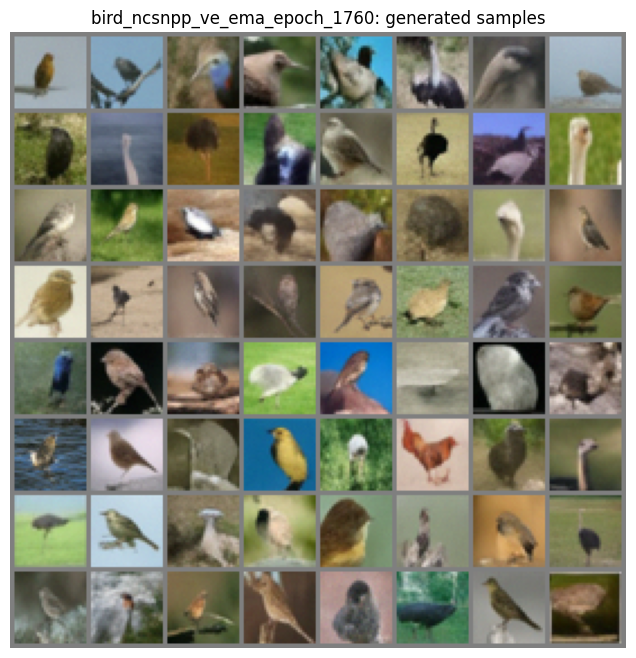

Installing torchmetrics and torch-fidelity...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 60.0MB/s]


Real images added to FID: 1000


100%|██████████| 999/999 [00:52<00:00, 19.01it/s]


Generated images added to FID: 64/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:39<00:00, 25.61it/s]


Generated images added to FID: 1000/1000
FID: 59.065773010253906
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:52<00:00, 19.00it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.0895695760846138
Median nearest-neighbor MSE: 0.08397173136472702
Minimum nearest-neighbor MSE: 0.017532994970679283
Maximum nearest-neighbor MSE: 0.2249501794576645


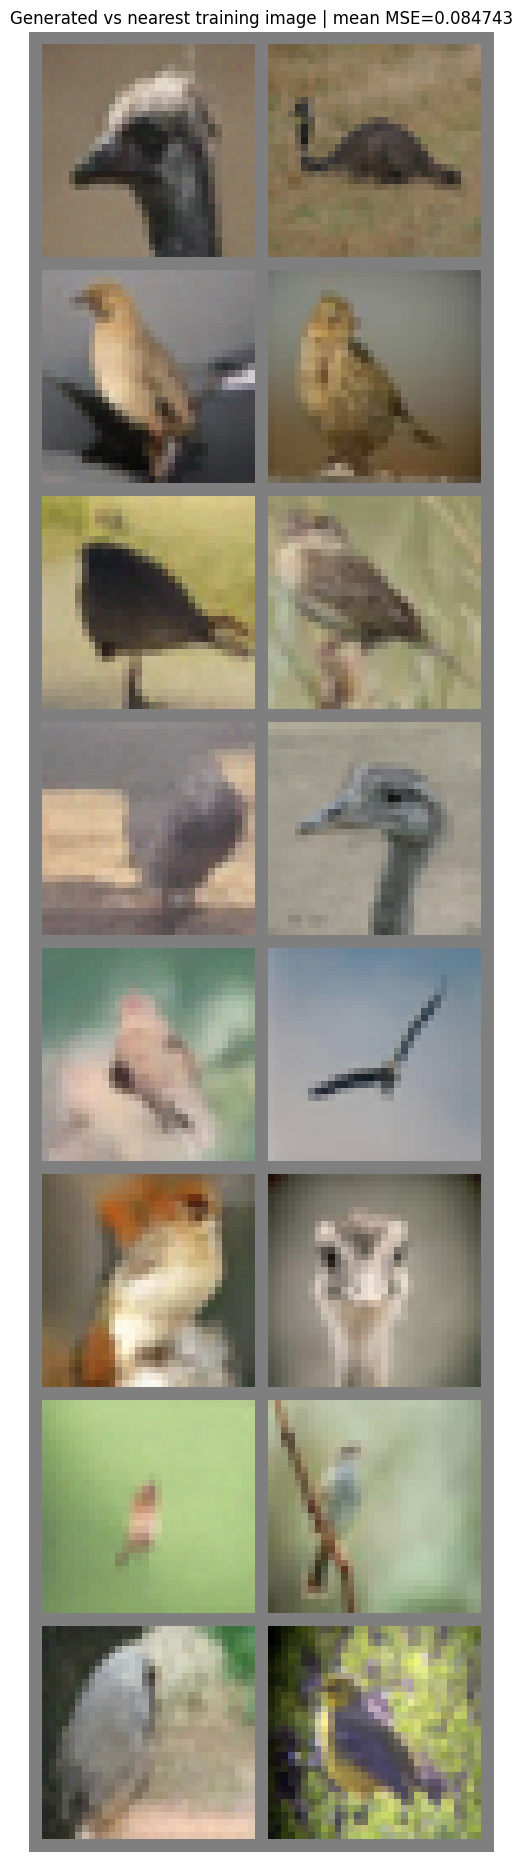

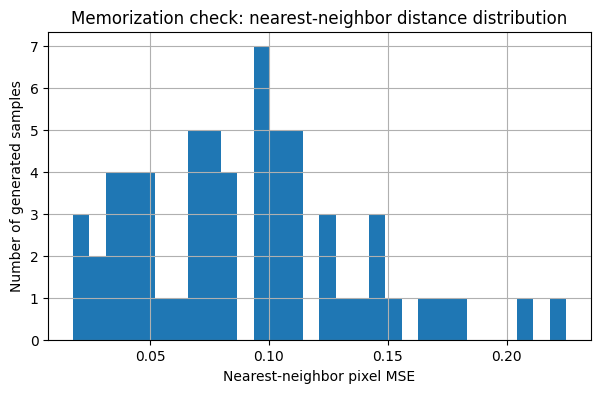

Saved memorization report: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_epoch_1760_memorization_report.txt
Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_ema_epoch_1760_evaluation_results.txt
{'model_name': 'bird_ncsnpp_ve_ema_epoch_1760', 'fid': 59.065773010253906, 'num_steps': 1000, 'corrector_steps': 1, 'mem_mean_nn_mse': 0.0895695760846138, 'mem_median_nn_mse': 0.08397173136472702, 'mem_min_nn_mse': 0.017532994970679283, 'mem_max_nn_mse': 0.2249501794576645}
Final EMA VE-SDE evaluation results:
{'model_name': 'bird_ncsnpp_ve_ema_epoch_1760', 'fid': 59.065773010253906, 'num_steps': 1000, 'corrector_steps': 1, 'mem_mean_nn_mse': 0.0895695760846138, 'mem_median_nn_mse': 0.08397173136472702, 'mem_min_nn_mse': 0.017532994970679283, 'mem_max_nn_mse': 0.2249501794576645}


In [ ]:
if RUN_EVALUATION_AFTER_LOADING:
    ema_ve_results = run_full_evaluation(model=ema_net, model_name="bird_ncsnpp_ve_ema_epoch_1760",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA VE-SDE evaluation results:")
    print(ema_ve_results)
else:
    print("Evaluation skipped because RUN_EVALUATION_AFTER_LOADING=False.")



Running full evaluation for: bird_ncsnpp_ve_epoch_1760


100%|██████████| 999/999 [00:52<00:00, 18.99it/s]


Generated 64/64 samples


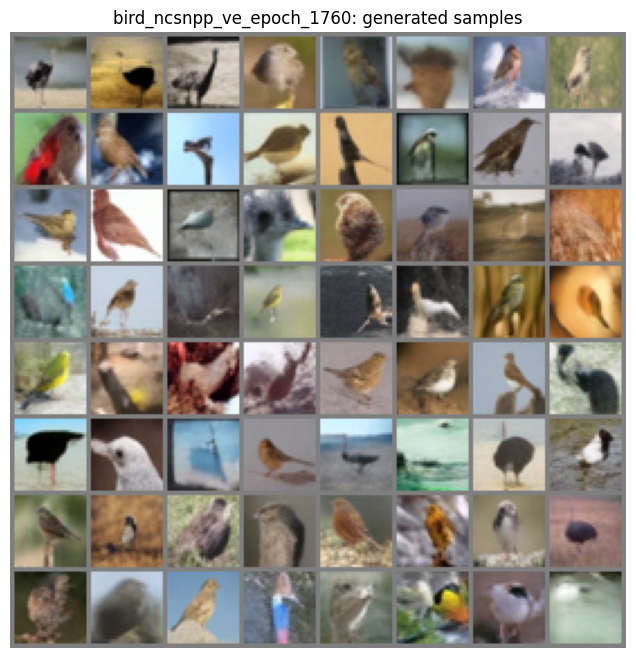

Real images added to FID: 1000


100%|██████████| 999/999 [00:52<00:00, 19.00it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:52<00:00, 19.00it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:39<00:00, 25.58it/s]


Generated images added to FID: 1000/1000
FID: 63.92619705200195
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:52<00:00, 18.96it/s]

Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.08939322829246521
Median nearest-neighbor MSE: 0.08394735306501389
Minimum nearest-neighbor MSE: 0.01912856101989746
Maximum nearest-neighbor MSE: 0.1858755201101303


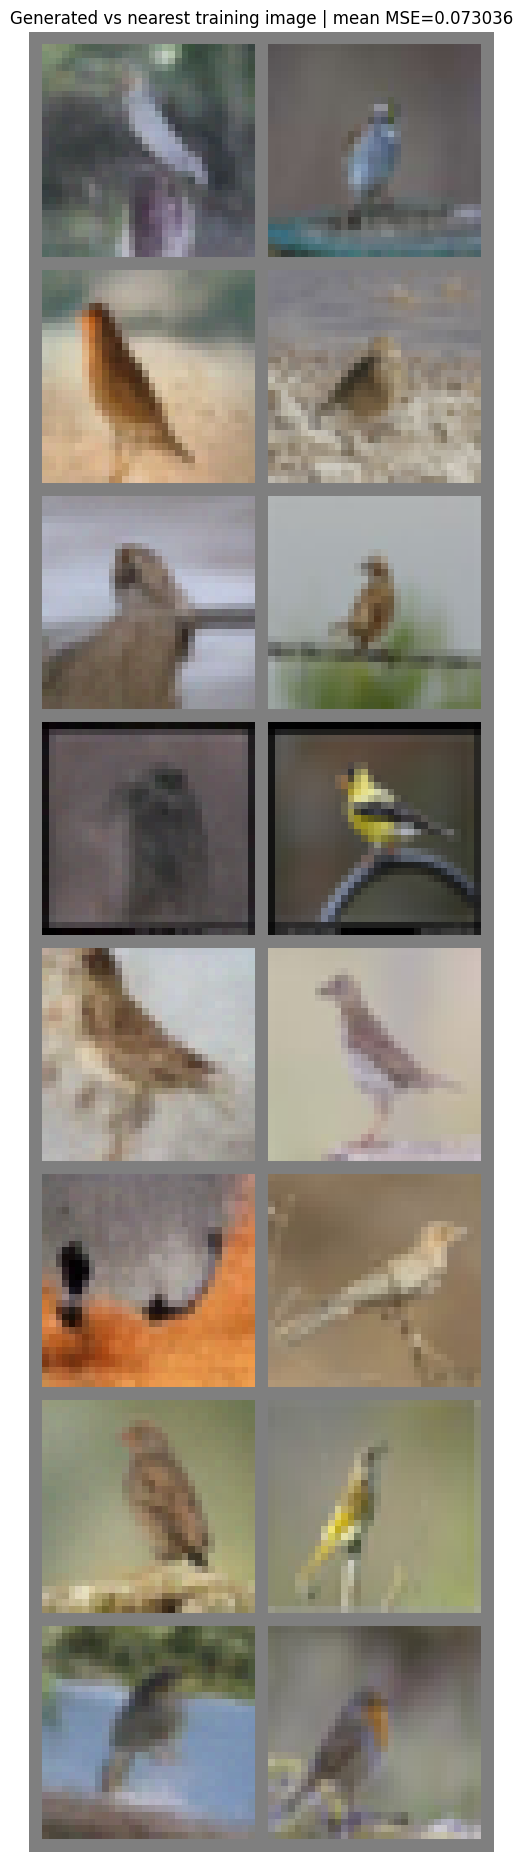

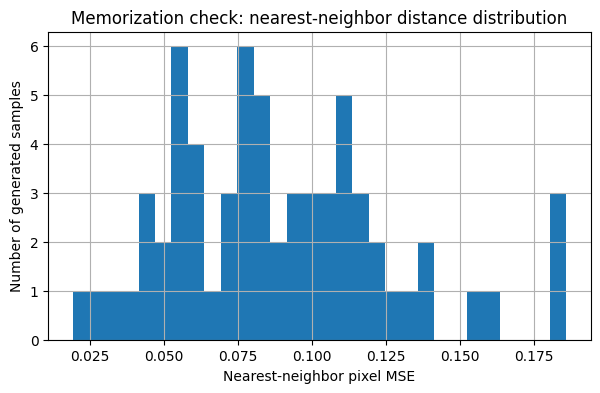

Saved memorization report: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_epoch_1760_memorization_report.txt
Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/bird_ncsnpp_ve_epoch_1760_evaluation_results.txt
{'model_name': 'bird_ncsnpp_ve_epoch_1760', 'fid': 63.92619705200195, 'num_steps': 1000, 'corrector_steps': 1, 'mem_mean_nn_mse': 0.08939322829246521, 'mem_median_nn_mse': 0.08394735306501389, 'mem_min_nn_mse': 0.01912856101989746, 'mem_max_nn_mse': 0.1858755201101303}
Final VE-SDE evaluation results:
{'model_name': 'bird_ncsnpp_ve_epoch_1760', 'fid': 63.92619705200195, 'num_steps': 1000, 'corrector_steps': 1, 'mem_mean_nn_mse': 0.08939322829246521, 'mem_median_nn_mse': 0.08394735306501389, 'mem_min_nn_mse': 0.01912856101989746, 'mem_max_nn_mse': 0.1858755201101303}


In [ ]:
if RUN_EVALUATION_AFTER_LOADING:
    ve_results = run_full_evaluation(model=ve_net, model_name="bird_ncsnpp_ve_epoch_1760",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final VE-SDE evaluation results:")
    print(ve_results)
else:
    print("Evaluation skipped because RUN_EVALUATION_AFTER_LOADING=False.")
